# Does a red first hour really call the close? 🌅🩸
### "88% of the time, the day closes red" — tested honestly, in plain English

Here's the hook, straight from a trading newsletter: on the S&P 500 futures, when the **first hour (9:30–10:30 ET) closes red** *and* the hour's **high prints before its low** (so the low looks set to break), the whole day closes red **88% of the time** — **90%** on the Nasdaq. The dashboard that found it was built *"in 5 minutes, one prompt, no code"* against an API. By 10:30 you supposedly already know how the day ends.

It sounds like a crystal ball. It is mostly a **head-start dressed up as a forecast** — plus a tiny, real grain of truth, plus the oldest trick in statistics. Let's pull those apart.

> ⚠️ **Not investment advice.** The reproducible core runs on a **synthetic** tape where we *bake in* the answer (a small, real morning→afternoon momentum, and an IB-rejection flag that is pure coin-flip noise). That's on purpose: it's where our tools *should* work, which proves the code — so the real-market numbers (quoted from [`../docs/results.md`](../docs/results.md)) are a measurement, not a hope.

*Follows the desk's seven beats ([METHODOLOGY.md](../../../METHODOLOGY.md)). The rigorous version is the companion,* [`02_for_the_quants.ipynb`](02_for_the_quants.ipynb).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))           # study root (crimson_hour/ lives there)
sys.path.insert(0, os.path.abspath("../../.."))      # repo root, for quantlab
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (9.5, 5.2)
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
from crimson_hour import data, signals, decompose

# Offline synthetic tape: sessions with a KNOWN afternoon momentum (0.12) and an IB-rejection
# flag drawn INDEPENDENTLY of the close -- so the decomposition has a ground truth to recover.
# The real verdict (SPY/QQQ + ES/NQ) is in ../docs/results.md via examples/verify.py.
feat, truth = data.synthetic_sessions(seed=0)
print(f"{len(feat)} synthetic sessions | baked-in momentum {truth.momentum} | "
      f"baseline red {truth.baseline_red:.1%} | IB flag null = {truth.ib_is_null}")


520 synthetic sessions | baked-in momentum 0.12 | baseline red 45.0% | IB flag null = True


## The answer first 🎯

| What we asked | The honest answer |
|---|---|
| Does a red first hour tilt the close red? | ✅ **Yes** — real and sizeable: on real SPY a red opening hour closes red **68.9%** of the time vs **45.8%** baseline. |
| Is that a *forecast* of the rest of the day? | ⚠️ **Mostly not** — strip the head-start and the *rest* of the day (10:30→close) is red just **50.9%** of the time. **71%** of the headline is mechanical. |
| Does the "IB-high rejection" add anything? | ❌ **No** — once the hour is red, the rejection flag changes nothing (Fisher p = 0.62). |
| So where does **88%** come from? | 🎰 **Small samples + cherry-picking** — a true ~70% edge, mined across a dozen "confluences" of 25 days, *expects* a best of **84.6%**. |

> Desk shorthand: **Signal `WEAK` · Tradability `MIRAGE` · "88% predictive?" `INFLATED`** — let's earn the stamps.

## 1 · The claim 📣

Two things you can see by 10:30 ET: the **opening candle** (the 9:30–10:30 hour) closes **red**, and within that hour the **high comes before the low** — the newsletter calls this *"IB-high rejection"*, the idea being the low is next to break. Stack them and, on the quoted sample, the day closed red **22 of 25 times (88%)** on ES and **28 of 31 (90%)** on NQ — against ~46% and ~45% baselines. The post is careful to call this *"bias, not a trade"* and ends with a free-dashboard sign-up. Our job is the space between *"88% on these 25 days"* and *"the morning predicts the day."*

## 2 · So what? 💰

If 10:30 really told you the close 9 times in 10, that would be one of the cleanest intraday edges anywhere — you'd lean every afternoon the morning's way and print. The subtler, likelier story is the one that actually helps you: a red first hour **does** tilt the day red, but mostly for a boring mechanical reason (the day is already *down* at 10:30 and just has to not fully climb back), with only a sliver of genuine *continuation* on top. Confuse the two and you'll bet real money on a "forecast" that's 70% bookkeeping.

## 3 · How we'd know 🔍

One clean split decides it. *"The day closes red"* is measured from the **9:30 open** — so if the first hour is red, the day starts the afternoon already in the hole. The honest question isn't *"does the day close red?"* but *"does the **rest of the day** (10:30→16:00) keep going down?"* — the part you don't yet know at 10:30. If the rest-of-day red rate barely beats a coin, the 88% is a head-start, not a crystal ball. We prove the split works on the synthetic, where we baked the answer in.

In [2]:
m = signals.condition_masks(feat)
tab = decompose.conditional_table(m, signals.session_red(feat))
print('P(session closes red | morning condition) — synthetic:')
display(tab.loc[['baseline','oc_red','confluence (oc_red & ib_rej)','oc_red & ib_NOT_rej']]
        [['k','n','rate','wilson_low','wilson_high','lift_pp']].round(3))

P(session closes red | morning condition) — synthetic:


,k,n,rate,wilson_low,wilson_high,lift_pp
baseline,234,520,0.4500,0.4080,0.4930,0.0000
oc_red,172,240,0.7170,0.6570,0.7700,26.6670
confluence (oc_red & ib_rej),91,120,0.7580,0.6740,0.8260,30.8330
oc_red & ib_NOT_rej,81,120,0.6750,0.5870,0.7520,22.5000


Notice already: the **confluence** and **OC-red-but-not-rejected** rows sit on top of each other — adding the rejection flag does nothing. The lift is the *red hour*, full stop.

## 4 · The teardown 🔬

Now the same machine on the **real tape** (from [`../docs/results.md`](../docs/results.md), via `examples/verify.py`). The chart below is the whole study in one picture: for each market, the **headline** lift (day closes red | red hour) next to the **honest** lift (rest-of-day red | red hour).

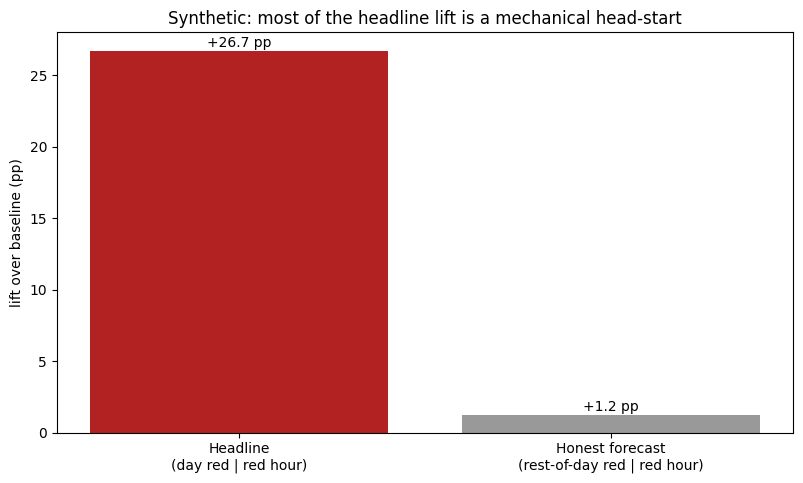

synthetic: 95% of the headline lift is mechanical, not forecast


In [3]:
# Synthetic illustration of the split (the real numbers are quoted below).
s = decompose.mechanical_vs_predictive(feat)
labels = ['Headline\n(day red | red hour)', 'Honest forecast\n(rest-of-day red | red hour)']
vals = [s['headline_lift_pp'], s['continuation_lift_pp']]
plt.bar(labels, vals, color=['#b22222','#999999'])
plt.axhline(0, color='k', lw=0.6); plt.ylabel('lift over baseline (pp)')
plt.title('Synthetic: most of the headline lift is a mechanical head-start')
for i,v in enumerate(vals): plt.text(i, v+0.3, f'{v:+.1f} pp', ha='center')
plt.show()
print(f"synthetic: {s['mechanical_share']:.0%} of the headline lift is mechanical, "
      f"not forecast")

**What the real tape says** (SPY = the S&P, QQQ = the Nasdaq, ~700 sessions each):

- A red first hour **does** tilt the close: SPY closes red **68.9%** of the time after a red hour (baseline 45.8%) — a real **+23.1 pp**. QQQ: **72.1%** (+27.0 pp). And the baselines (~46%, ~45%) match the newsletter's own 46.1% / 44.5% almost exactly — so this *is* the same effect.
- But the **rest of the day** barely continues: SPY rest-of-day red just **50.9%** (+6.7 pp over baseline), QQQ **49.0%** (+5.6 pp). So **71%–79%%** of the famous lift is the head-start; the genuine forecast is ~6 points of tilt.
- The **IB-rejection adds nothing**: on the real ES tape the full confluence (5/11 = 45.5%) is statistically the same as a red hour that *wasn't* rejected (Fisher p = 0.62; NQ p = 1.00).
- And **88% is what mining produces**: a true ~70.5% edge, taken as the best of a dozen 25-day "confluences," *expects* a top score of **84.6%** (95th pct 92.0%) — reaching 88% by luck alone happens **36.2%** of the time.

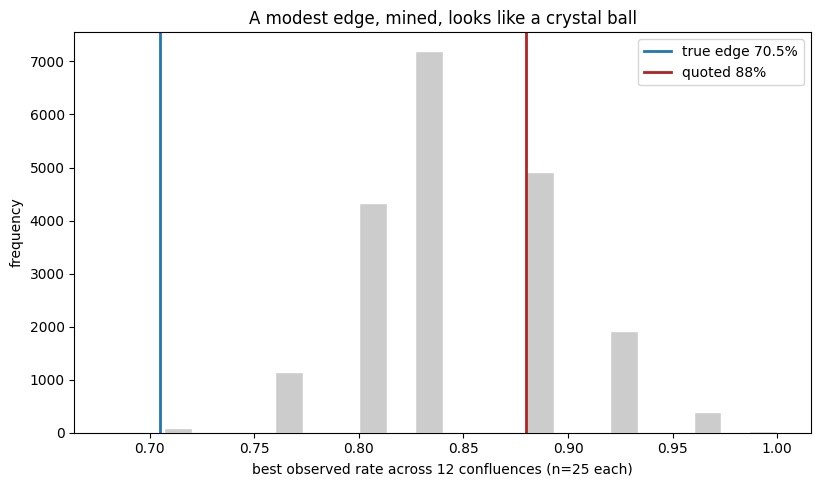

In [4]:
# Why 'best of several tiny samples' manufactures a headline (synthetic Monte-Carlo).
rng = np.random.default_rng(0)
best = (rng.binomial(25, 0.705, size=(20000, 12)) / 25).max(axis=1)
plt.hist(best, bins=24, color='#cccccc', edgecolor='white')
plt.axvline(0.705, color='#1f77b4', lw=2, label='true edge 70.5%')
plt.axvline(0.88, color='#b22222', lw=2, label='quoted 88%')
plt.xlabel('best observed rate across 12 confluences (n=25 each)')
plt.ylabel('frequency'); plt.legend(); plt.title('A modest edge, mined, looks like a crystal ball')
plt.show()

## 5 · The verdict ⚖️

**Signal `WEAK`** — there's a real morning→afternoon continuation, but it's ~6 points of tilt, and ~3/4 of the headline is a mechanical head-start; the IB-rejection leg is nothing. **Tradability `MIRAGE`** — a *bias on the direction of the close* isn't an entry, and 6 points of directional tilt won't survive the spread and a sensible target. **"88% predictive?" `INFLATED`** — it's a small-sample, cherry-picked draw from a ~70% true rate. The newsletter's own hedge — *"bias, not a trade"* — is the honest read.

## 6 · Could you trade it? 🏦

We actually ran the trade. Short the rest of the day whenever the first hour is red, cover at the close (this is the *one* positive-expectancy way to play it). On real SPY it makes **+2.19 bps per trade** before costs — which sounds like something until you see the two catches.

**First, it might be luck:** that gross number has a *t*-stat of just **+0.68** (QQQ +0.91) — statistically indistinguishable from zero. **Second, costs eat it:** the trade only breaks even if your round-trip cost stays under **2.19 bps** (QQQ 3.70 bps), and a realistic intraday round-trip — spread, slippage, and the fact you can't perfectly hit the 4 pm print, *twice* a day — lands right there. Charge a sensible 2 bps and SPY's risk-adjusted return collapses to **+0.03** (a flat line). The continuation is a real *lean*; as a *trade* it's noise that dies on the spread. The newsletter's own words — *bias, not a trade* — are exactly right.

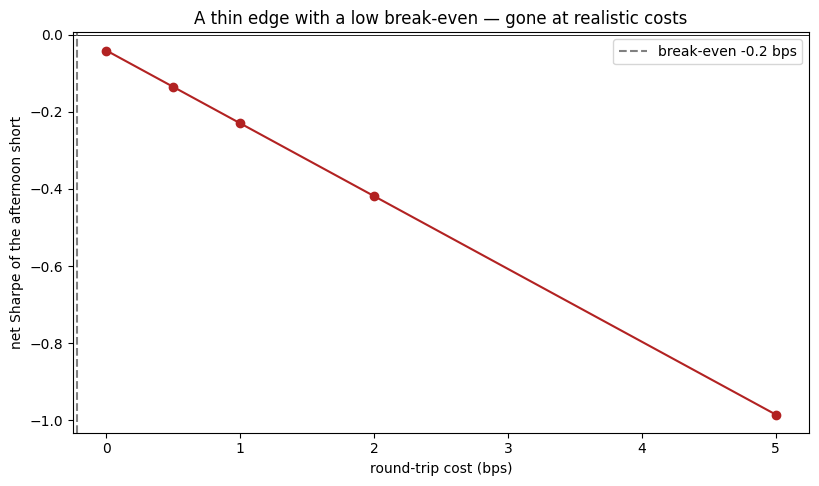

In [5]:
# The afternoon short, cost-swept (synthetic illustration; real numbers quoted above).
bt = decompose.afternoon_short_backtest(feat)
costs = [0.0, 0.5, 1.0, 2.0, 5.0]
nets = [bt['net'][c]['net_sharpe'] for c in costs]
plt.plot(costs, nets, 'o-', color='#b22222')
plt.axhline(0, color='k', lw=0.6)
plt.axvline(bt['break_even_cost_bps'], color='grey', ls='--',
            label=f"break-even {bt['break_even_cost_bps']:.1f} bps")
plt.xlabel('round-trip cost (bps)'); plt.ylabel('net Sharpe of the afternoon short')
plt.title('A thin edge with a low break-even — gone at realistic costs'); plt.legend()
plt.show()

## 7 · Going further 🚪

- **Make the head-start explicit:** for each red-hour day, plot how much of the close-red outcome was already locked in by 10:30 vs decided after.
- **Does the tilt survive costs?** Back-test the 10:30→close short on real bars with a realistic spread and a profit target — find the break-even cost.
- **Other sessions / regimes:** the baseline red rate swung from ~46% (the quoted window) to ~33% in our recent 60-day futures sample — the "88%" is partly *when* you look. Map the conditional rate across rolling windows.

The deep version — Wilson intervals, the beta-binomial posterior on 22/25, the two-proportion tests, and the mining Monte-Carlo — is in [`02_for_the_quants.ipynb`](02_for_the_quants.ipynb).